In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
itsahmad_indoor_scenes_cvpr_2019_path = kagglehub.dataset_download('itsahmad/indoor-scenes-cvpr-2019')
benjaminkz_places365_path = kagglehub.dataset_download('benjaminkz/places365')

print('Data source import complete.')


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import time
import matplotlib.pyplot as plt
import os

import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


In [ ]:
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
basePath = "/kaggle/input/indoor-scenes-cvpr-2019"
imgDir = os.path.join(basePath, "indoorCVPR_09", "Images")
trainLabelFile = os.path.join(basePath, "TrainImages.txt")
valLabelFile = os.path.join(basePath, "TestImages.txt")

print("First 5 image files in Images folder:", os.listdir(imgDir)[:5])

# Transform
dataTransform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

First 5 image files in Images folder: ['meeting_room', 'grocerystore', 'trainstation', 'mall', 'bar']


In [ ]:
class Indoor67Dataset(Dataset):
    def __init__(self, imgDir, txtFile, transform=None):
        self.samples = []
        self.transform = transform

        with open(txtFile) as f:
            for line in f:
                imgName = line.strip()
                if imgName:
                    # Extract label from folder name
                    label = imgName.split('/')[0]
                    fullPath = os.path.join(imgDir, imgName)
                    if os.path.isfile(fullPath):
                        self.samples.append((fullPath, label))
                    else:
                        print(f"⚠ Missing file: {fullPath}")

        self.classes = sorted(set(lbl for _, lbl in self.samples))
        self.classToIdx = {cls: i for i, cls in enumerate(self.classes)}

        print(f"Loaded {len(self.samples)} samples from {txtFile}")
        if self.samples:
            print("Example sample:", self.samples[0])
        else:
            print("No valid samples found!")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.classToIdx[label]


In [ ]:
# Load datasets
trainDataset = Indoor67Dataset(imgDir, trainLabelFile, transform=dataTransform)
valDataset = Indoor67Dataset(imgDir, valLabelFile, transform=dataTransform)

# DataLoaders
trainLoader = DataLoader(trainDataset, batch_size=64, shuffle=True, num_workers=4)
valLoader = DataLoader(valDataset, batch_size=64, shuffle=False, num_workers=4)

# Classes info
print("Classes:", trainDataset.classes)
print(f"Number of classes: {len(trainDataset.classes)}")

Loaded 5360 samples from /kaggle/input/indoor-scenes-cvpr-2019/TrainImages.txt
Example sample: ('/kaggle/input/indoor-scenes-cvpr-2019/indoorCVPR_09/Images/gameroom/bt_132294gameroom2.jpg', 'gameroom')
Loaded 1340 samples from /kaggle/input/indoor-scenes-cvpr-2019/TestImages.txt
Example sample: ('/kaggle/input/indoor-scenes-cvpr-2019/indoorCVPR_09/Images/kitchen/int474.jpg', 'kitchen')
Classes: ['airport_inside', 'artstudio', 'auditorium', 'bakery', 'bar', 'bathroom', 'bedroom', 'bookstore', 'bowling', 'buffet', 'casino', 'children_room', 'church_inside', 'classroom', 'cloister', 'closet', 'clothingstore', 'computerroom', 'concert_hall', 'corridor', 'deli', 'dentaloffice', 'dining_room', 'elevator', 'fastfood_restaurant', 'florist', 'gameroom', 'garage', 'greenhouse', 'grocerystore', 'gym', 'hairsalon', 'hospitalroom', 'inside_bus', 'inside_subway', 'jewelleryshop', 'kindergarden', 'kitchen', 'laboratorywet', 'laundromat', 'library', 'livingroom', 'lobby', 'locker_room', 'mall', 'meeti

In [ ]:
numClasses = len(trainDataset.classes)
print(f"Number of classes: {numClasses}")

Number of classes: 67


In [ ]:
# Model
model = models.mobilenet_v2(pretrained=True)
for param in model.features.parameters():
    param.requires_grad = False

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 118MB/s]


In [ ]:
model.classifier[1] = nn.Linear(model.last_channel, numClasses)
model = model.to(device)

In [ ]:
# Loss, optimizer, scheduler
lossFunction = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

In [ ]:
# DataLoaders
'''trainLoader = DataLoader(trainDataset, batch_size=64, shuffle=True, num_workers=4)
valLoader = DataLoader(valDataset, batch_size=64, shuffle=False, num_workers=4)

trainLoader = DataLoader(trainDataset, batch_size=64, shuffle=True, num_workers=2)
valLoader = DataLoader(valDataset, batch_size=64, shuffle=False, num_workers=2)

print("Train samples:", len(trainDataset))
print("Val samples:", len(valDataset))'''

Train samples: 2000
Val samples: 1000


In [ ]:
# Number of classes
numClasses = len(trainDataset.classes)
print(f"Number of classes: {numClasses}")


Number of classes: 365


In [ ]:
model = models.mobilenet_v2(pretrained=True)

# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier
model.classifier[1] = nn.Linear(model.last_channel, numClasses)
model = model.to(device)


In [ ]:
lossFunction = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)


In [ ]:
def trainModel(model, trainLoader, valLoader, numEpochs=5):
    trainLosses, valLosses = [], []
    trainAccuracies, valAccuracies = [], []

    for epoch in range(numEpochs):
        model.train()
        totalLoss, correct, total = 0.0, 0, 0
        startTime = time.time()

        for xb, yb in trainLoader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = lossFunction(preds, yb)
            loss.backward()
            optimizer.step()

            totalLoss += loss.item()
            correct += (preds.argmax(1) == yb).sum().item()
            total += yb.size(0)

        trainAcc = correct / total
        avgTrainLoss = totalLoss / len(trainLoader)
        trainLosses.append(avgTrainLoss)
        trainAccuracies.append(trainAcc)

        # Validation
        model.eval()
        valLoss, valCorrect, valTotal = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in valLoader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                valLoss += lossFunction(preds, yb).item()
                valCorrect += (preds.argmax(1) == yb).sum().item()
                valTotal += yb.size(0)

        valAcc = valCorrect / valTotal
        avgValLoss = valLoss / len(valLoader)
        valLosses.append(avgValLoss)
        valAccuracies.append(valAcc)

        scheduler.step()

        print(f"Epoch [{epoch+1}/{numEpochs}] - "
              f"Train Acc: {trainAcc:.4f}, Loss: {avgTrainLoss:.4f} | "
              f"Val Acc: {valAcc:.4f}, Loss: {avgValLoss:.4f} | "
              f"Time: {time.time() - startTime:.1f}s")

    return trainLosses, trainAccuracies, valLosses, valAccuracies


Epoch [1/5] - Train Acc: 0.2756, Loss: 3.1736 | Val Acc: 0.5381, Loss: 2.2381 | Time: 31.8s
Epoch [2/5] - Train Acc: 0.5882, Loss: 1.8412 | Val Acc: 0.5806, Loss: 1.7045 | Time: 24.0s
Epoch [3/5] - Train Acc: 0.6743, Loss: 1.4097 | Val Acc: 0.6149, Loss: 1.4982 | Time: 23.9s
Epoch [4/5] - Train Acc: 0.7326, Loss: 1.1675 | Val Acc: 0.6351, Loss: 1.4147 | Time: 23.9s
Epoch [5/5] - Train Acc: 0.7455, Loss: 1.1007 | Val Acc: 0.6276, Loss: 1.3760 | Time: 23.6s


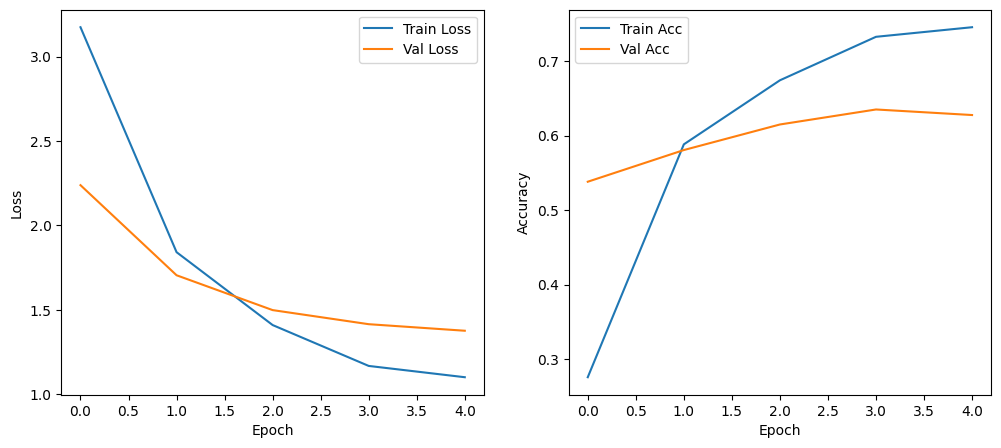

In [ ]:
trainLosses, trainAccs, valLosses, valAccs = trainModel(model, trainLoader, valLoader, numEpochs=5)

# Example plot both loss and accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(trainLosses, label='Train Loss')
plt.plot(valLosses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(trainAccs, label='Train Acc')
plt.plot(valAccs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
modelSavePath = "mobilenet_indoor.pth"
torch.save(model.state_dict(), modelSavePath)
print(f"Model saved to: {modelSavePath}")

Model saved to: mobilenet_indoor.pth


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluateModel(model, dataLoader, classNames):
    model.eval()
    allPreds = []
    allLabels = []

    with torch.no_grad():
        for xb, yb in dataLoader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            preds = outputs.argmax(dim=1)
            allPreds.extend(preds.cpu().numpy())
            allLabels.extend(yb.cpu().numpy())

    # Accuracy
    accuracy = sum(p == l for p, l in zip(allPreds, allLabels)) / len(allLabels)
    print(f"\n Evaluation Accuracy: {accuracy:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(allLabels, allPreds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=classNames[:30], yticklabels=classNames[:30])  # plot only top 30 for visibility
    plt.title("Confusion Matrix (Top 30 Classes)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Classification Report
    print("\n Classification Report (Partial):")
    #print(classification_report(allLabels, allPreds, target_names=classNames[:10]))
    print(classification_report(allLabels, allPreds, target_names=classNames))




 Evaluation Accuracy: 0.6276


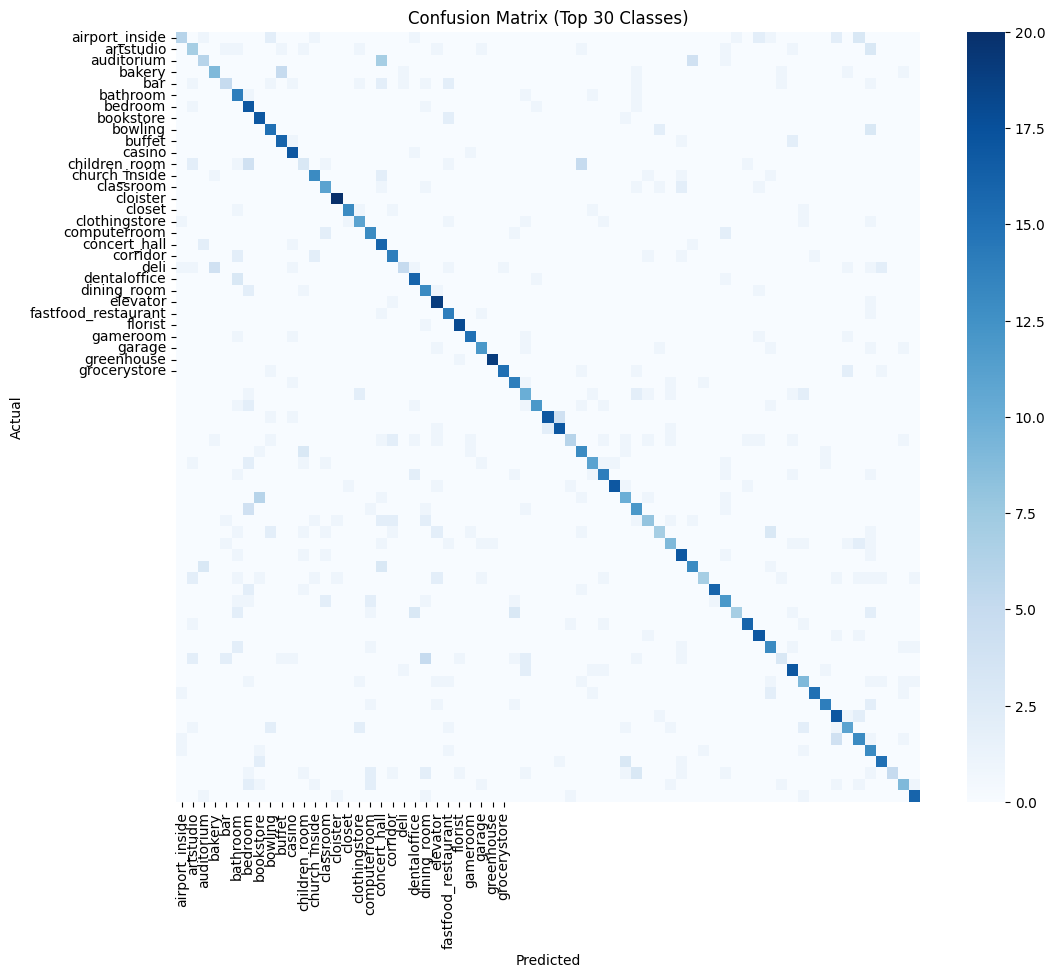


 Classification Report (Partial):
                     precision    recall  f1-score   support

     airport_inside       0.55      0.30      0.39        20
          artstudio       0.37      0.35      0.36        20
         auditorium       0.46      0.33      0.39        18
             bakery       0.60      0.47      0.53        19
                bar       0.50      0.28      0.36        18
           bathroom       0.42      0.78      0.55        18
            bedroom       0.42      0.81      0.56        21
          bookstore       0.59      0.85      0.69        20
            bowling       0.60      0.75      0.67        20
             buffet       0.70      0.80      0.74        20
             casino       0.68      0.89      0.77        19
      children_room       0.23      0.17      0.19        18
      church_inside       0.68      0.68      0.68        19
          classroom       0.58      0.61      0.59        18
           cloister       0.87      1.00      0.9

In [ ]:
# Evaluate model on validation data
evaluateModel(model, valLoader, trainDataset.classes)

